In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import time
from prometheus_api_client import PrometheusConnect
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from scipy.stats import zscore

# Prometheus bağlantısı
prom = PrometheusConnect(url="http://localhost:9090", disable_ssl=True)
print("Prometheus baglantisi kuruldu!")

# Son 1 saatin verisini çek
METRIKLER = {
    "cpu": 'avg(rate(node_cpu_seconds_total{mode!="idle", job="node-exporter"}[2m])) / avg(rate(node_cpu_seconds_total{job="node-exporter"}[2m])) * 100',
    "bellek": '100 - ((avg(node_memory_MemAvailable_bytes{job="node-exporter"}) / avg(node_memory_MemTotal_bytes{job="node-exporter"})) * 100)',
    "network_in": 'sum(rate(node_network_receive_bytes_total{job="node-exporter"}[2m]))',
    "network_out": 'sum(rate(node_network_transmit_bytes_total{job="node-exporter"}[2m]))',
    "disk": 'sum(rate(node_disk_read_bytes_total{job="node-exporter"}[2m]))',
}

simdi     = pd.Timestamp.now()
baslangic = simdi - pd.Timedelta(hours=1)

df_liste = []
for metrik_adi, sorgu in METRIKLER.items():
    try:
        sonuc = prom.custom_query_range(
            query      = sorgu,
            start_time = baslangic.to_pydatetime(),
            end_time   = simdi.to_pydatetime(),
            step       = "15s"
        )
        if sonuc:
            for seri in sonuc:
                for ts, val in seri["values"]:
                    try:
                        df_liste.append({
                            "timestamp": pd.Timestamp(ts, unit="s"),
                            "metrik"   : metrik_adi,
                            "value"    : float(val)
                        })
                    except:
                        continue
    except Exception as e:
        print(f"{metrik_adi} hatasi: {e}")

df_raw = pd.DataFrame(df_liste)
df_raw["value"] = df_raw["value"].clip(lower=0)

print(f"Toplam veri noktasi: {len(df_raw)}")
print(f"Metrikler: {df_raw['metrik'].unique()}")
print(f"Zaman araligi: {df_raw['timestamp'].min()} → {df_raw['timestamp'].max()}")
print(df_raw.groupby("metrik")["value"].describe())

Prometheus baglantisi kuruldu!
Toplam veri noktasi: 496
Metrikler: ['cpu' 'bellek' 'network_in' 'network_out' 'disk']
Zaman araligi: 2026-06-02 21:02:05 → 2026-06-02 21:26:50
             count           mean            std         min         25%  \
metrik                                                                     
bellek       100.0      20.830274       1.216821   18.871986   19.593598   
cpu           99.0       0.414102       0.136515    0.255230    0.320179   
disk          99.0  237638.684611  499287.813020    0.000000  156.974692   
network_in    99.0      59.214807       7.727777   12.149428   57.965831   
network_out   99.0     943.847455     132.045740  185.999299  893.142045   

                    50%            75%           max  
metrik                                                
bellek        21.306647      21.402210  2.272164e+01  
cpu            0.392637       0.419592  8.760384e-01  
disk         742.602506  159462.333484  1.835650e+06  
network_in    61.

In [2]:
# Veriyi pivot et — her metrik bir sütun olsun
df_pivot = df_raw.pivot_table(
    index="timestamp",
    columns="metrik",
    values="value"
).reset_index()

df_pivot.columns.name = None
df_pivot = df_pivot.dropna().reset_index(drop=True)

print(f"Pivot veri boyutu: {df_pivot.shape}")
print(df_pivot.head())

Pivot veri boyutu: (99, 6)
            timestamp     bellek       cpu        disk  network_in  \
0 2026-06-02 21:02:20  20.327636  0.255230   65.221567   12.149428   
1 2026-06-02 21:02:35  20.340591  0.276034  195.935536   18.249367   
2 2026-06-02 21:02:50  20.380162  0.288501  176.236303   33.431545   
3 2026-06-02 21:03:05  20.338071  0.291728  165.739392   39.583633   
4 2026-06-02 21:03:20  20.378851  0.297492  159.922441   45.641927   

   network_out  
0   185.999299  
1   279.313377  
2   503.075906  
3   591.802120  
4   685.312170  


In [3]:
# Özellik mühendisliği
metrik_sutunlar = ["cpu", "bellek", "disk", "network_in", "network_out"]
pencere = 5

for col in metrik_sutunlar:
    df_pivot[f"{col}_rolling_mean"] = df_pivot[col].rolling(pencere).mean()
    df_pivot[f"{col}_rolling_std"]  = df_pivot[col].rolling(pencere).std()
    df_pivot[f"{col}_diff"]         = df_pivot[col].diff()

df_pivot = df_pivot.dropna().reset_index(drop=True)

# Özellik matrisi
feature_cols = (
    metrik_sutunlar +
    [f"{c}_rolling_mean" for c in metrik_sutunlar] +
    [f"{c}_rolling_std"  for c in metrik_sutunlar] +
    [f"{c}_diff"         for c in metrik_sutunlar]
)

X = df_pivot[feature_cols].values

print(f"Eğitim verisi boyutu : {X.shape}")
print(f"Özellik sayısı       : {len(feature_cols)}")
print(f"Özellikler           : {feature_cols}")

Eğitim verisi boyutu : (95, 20)
Özellik sayısı       : 20
Özellikler           : ['cpu', 'bellek', 'disk', 'network_in', 'network_out', 'cpu_rolling_mean', 'bellek_rolling_mean', 'disk_rolling_mean', 'network_in_rolling_mean', 'network_out_rolling_mean', 'cpu_rolling_std', 'bellek_rolling_std', 'disk_rolling_std', 'network_in_rolling_std', 'network_out_rolling_std', 'cpu_diff', 'bellek_diff', 'disk_diff', 'network_in_diff', 'network_out_diff']


In [4]:
# Ölçeklendir ve modeli eğit
scaler_prom = StandardScaler()
X_scaled    = scaler_prom.fit_transform(X)

model_prom = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
model_prom.fit(X_scaled)
print("✅ Prometheus modeli egitildi!")

# Anomali skorlarını hesapla
if_score = -model_prom.decision_function(X_scaled)
if_norm  = (if_score - if_score.min()) / (if_score.max() - if_score.min() + 1e-9)

z_scores = np.abs(zscore(X_scaled))
max_z    = np.nan_to_num(z_scores.max(axis=1), nan=0.0)
z_norm   = (max_z - max_z.min()) / (max_z.max() - max_z.min() + 1e-9)

df_pivot["hybrid_score"] = 0.4 * if_norm + 0.6 * z_norm
df_pivot["anomaly_pred"] = (df_pivot["hybrid_score"] >= 0.35).astype(int)

print(f"\nTespit edilen anomali : {df_pivot['anomaly_pred'].sum()}")
print(f"Anomali orani         : %{df_pivot['anomaly_pred'].mean()*100:.2f}")

# Modeli kaydet
os.makedirs("models", exist_ok=True)

with open("models/prometheus_model.pkl",    "wb") as f: pickle.dump(model_prom,   f)
with open("models/prometheus_scaler.pkl",   "wb") as f: pickle.dump(scaler_prom,  f)
with open("models/prometheus_features.pkl", "wb") as f: pickle.dump(feature_cols, f)
with open("models/prometheus_threshold.pkl","wb") as f: pickle.dump(0.35,         f)
with open("models/prometheus_metrics.pkl",  "wb") as f: pickle.dump(metrik_sutunlar, f)

print("\n✅ Model kaydedildi!")
print("📁 Kaydedilen dosyalar:")
for f in sorted(os.listdir("models")):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"   {f:<40} {size:.1f} KB")

✅ Prometheus modeli egitildi!

Tespit edilen anomali : 17
Anomali orani         : %17.89

✅ Model kaydedildi!
📁 Kaydedilen dosyalar:
   nab_features.pkl                         0.1 KB
   nab_model.pkl                            722.1 KB
   nab_scaler.pkl                           0.6 KB
   nab_threshold.pkl                        0.0 KB
   prometheus_features.pkl                  0.4 KB
   prometheus_metrics.pkl                   0.1 KB
   prometheus_model.pkl                     1128.5 KB
   prometheus_scaler.pkl                    0.9 KB
   prometheus_threshold.pkl                 0.0 KB
   threshold.pkl                            0.0 KB


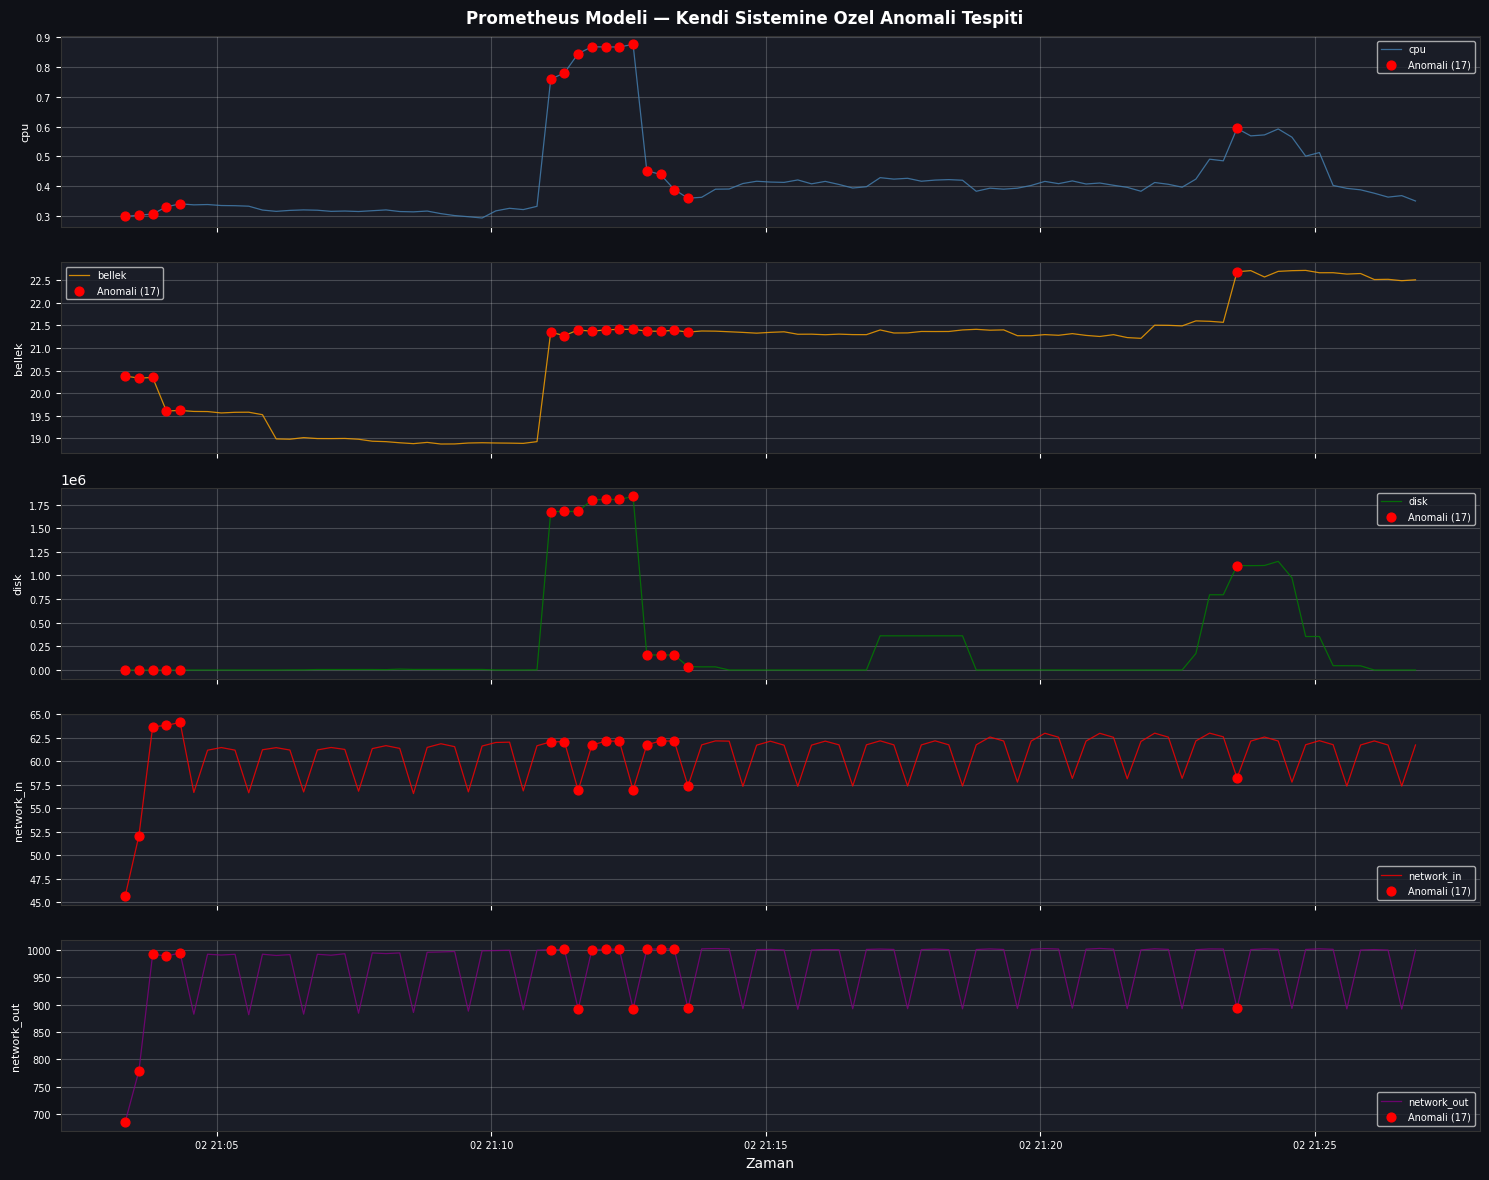

✅ Grafik kaydedildi!


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)
fig.patch.set_facecolor("#0F1117")

renkler = ["steelblue", "orange", "green", "red", "purple"]

for i, (col, renk) in enumerate(zip(metrik_sutunlar, renkler)):
    ax = axes[i]
    ax.set_facecolor("#1A1D27")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")

    ax.plot(df_pivot["timestamp"], df_pivot[col],
            color=renk, linewidth=0.9, alpha=0.8, label=col)

    anomaliler = df_pivot[df_pivot["anomaly_pred"] == 1]
    if len(anomaliler) > 0:
        ax.scatter(anomaliler["timestamp"], anomaliler[col],
                   color="red", s=40, zorder=5,
                   label=f"Anomali ({len(anomaliler)})")

    ax.set_ylabel(col, color="white", fontsize=8)
    ax.tick_params(colors="white", labelsize=7)
    ax.legend(fontsize=7, facecolor="#1A1D27", labelcolor="white")
    ax.grid(True, alpha=0.2, color="white")

axes[-1].set_xlabel("Zaman", color="white")
fig.suptitle("Prometheus Modeli — Kendi Sistemine Ozel Anomali Tespiti",
             color="white", fontsize=12, fontweight="bold")
plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/prometheus_model.png", dpi=150,
            facecolor="#0F1117", bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi!")